# Notebook 8 Baboon data - fortsættelse 

Jeg arbejder med data fra bavianer (*P. Papio*) baseret på Sørensen et al. (2023). Datasættet indeholder VCF/VCZ-data for kromosom 20 med:

- 227 diploide individer (454 haploide genomer)
- Multiple bavian-arter og populationer

Bavian-arter i datasættet - 6 arter:

- *P. cynocephalus* (Yellow bavian) 
- *P. kindae* (Kinda bavian)   
- *P. anubis* (Olive bavian) 
- *P. papio* (Guinea bavian) 
- *P. ursinus* (Chacma bavian) 
- *P. hamadryas* (Hamadryas bavian)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

# Importer nødvendige pakker
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level,
)
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

DATA_DIR = Path("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR")
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Biologiske konstanter fra Sørensen et al. 2023
MUT_RATE = 0.9e-8   # mutationsrate per site per generation
GEN_TIME = 11       # generationstid i år

print("Imports OK")

Imports OK


## Indlæser dataen

In [2]:
# loader data for chr20 
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")

variant_allele_counts = sg.count_variant_alleles(ds) # variant_allele_count har shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   # triggers compute
nr_samples = ac.sum(axis=1)  # nr haploid samples (chromosomes)

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


In [3]:
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # P. cynocephalus - Tanzania (Ruaha + Udzungwa + Mahale + Katavi + Selous + Mikumi + Issa Valley)                                                         
    "P_cynocephalus":  ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216','PD_0217', 'PD_0223',
                         'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228', 'PD_0229',
                         'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234', 'PD_0235',
                         'PD_0236', 'PD_0237', 'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232',
                         'PD_0233', 'PD_0234', 'PD_0235', 'PD_0236', 'PD_0237', 'PD_0268',
                         'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272', 'PD_0503', 'PD_0637',
                         'PD_0658', 'PD_0659','PD_0662', 'PD_0687', 'PD_0688', 'PD_0689',
                         'PD_0690', 'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747', 'PD_0748',
                         'PD_0752', 'PD_0753', 'PD_0754', 'PD_0755', 'PD_0756', 'PD_0757',
                         'PD_0761', 'PD_0762', 'PD_0763', 'PD_0764', 'PD_0765', 'PD_0766',
                         'PD_0767', 'PD_0768', 'PD_0769', 'PD_0770', 'PD_0771', 'PD_0772',
                         'PD_0773', 'PD_0774', 'PD_0775'],
    # P. Kindae - Chunga, Zambia      
    "P_kindae":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB'],
    # P. Anubis - Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire, Gombe, Arusha), Ethiopia (Gog)
    "P_anubis":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0218', 'PD_0219', 
                            'PD_0220', 'PD_0221', 'PD_0222', 'PD_0238', 'PD_0239', 'PD_0240', 
                            'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
                            'PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_0496', 
                            'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501', 'PD_0502', 
                            'PD_0504', 'PD_0505', 'PD_0506', 'PD_0507', 'PD_0508', 'PD_0509', 
                            'PD_0641', 'PD_0642', 'PD_0649', 'PD_0650', 'PD_0651', 'PD_0652',
                            'PD_0653', 'PD_0654', 'PD_0674', 'PD_0675', 'PD_0676', 'PD_0677', 
                            'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682', 'PD_0683', 
                            'PD_0684', 'PD_0685', 'PD_0686', 'PD_0719', 'PD_0720', 'PD_0721', 
                            'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726', 'PD_0727', 
                            'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733', 
                            'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738' 'PD_0739', 
                            'PD_0740', 'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'],
    # P. Papio - Niokolo Koba, Senegal
    "P_papio":          ['PD_0390', 'PD_0391',
                         'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395', 'PD_0396', 'PD_0397', 
                         'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401', 'PD_0397', 'PD_0398', 
                         'PD_0399', 'PD_0400', 'PD_0401'],
    # P. Ursinus (Grayfoot) - Dendro Park, Zambia
    "P_ursinus":        ['PD_0692', 'PD_0693', 'PD_0694', 'PD_0695', 'PD_0695'],
    # P. Hamadryas - Filoha, Ethiopia
    "P_hamadryas":     ['PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701',
                        'PD_0702', 'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707',
                        'PD_0708', 'PD_0709', 'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713',
                        'PD_0714', 'PD_0715', 'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719', 
                        'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
                        'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 
                        'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719'],                            
                                        
}

In [5]:
# Udtrækker subsets 
keep = population_map["P_cynocephalus"]
mask = ds["sample_id"].isin(keep).values
ds_P_cynocephalus = ds.isel(samples=mask)

keep = population_map["P_kindae"]
mask = ds["sample_id"].isin(keep).values
ds_P_kindae = ds.isel(samples=mask)

keep = population_map["P_anubis"]
mask = ds["sample_id"].isin(keep).values
ds_P_anubis = ds.isel(samples=mask)

keep = population_map["P_papio"]
mask = ds["sample_id"].isin(keep).values
ds_P_papio = ds.isel(samples=mask)

keep = population_map["P_ursinus"]
mask = ds["sample_id"].isin(keep).values
ds_P_ursinus = ds.isel(samples=mask)

keep = population_map["P_hamadryas"]
mask = ds["sample_id"].isin(keep).values
ds_P_hamadryas = ds.isel(samples=mask)


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Yellow baboon: {ds_P_cynocephalus.dims['samples']} samples")
print(f"Kinda baboon:  {ds_P_kindae.dims['samples']} samples")
print(f"Olive baboon: {ds_P_anubis.dims['samples']} samples")
print(f"Guinea baboon: {ds_P_papio.dims['samples']} samples")
print(f"Chacma baboon: {ds_P_ursinus.dims['samples']} samples")
print(f"Hamadryas baboon: {ds_P_hamadryas.dims['samples']} samples")

Yellow baboon: 60 samples
Kinda baboon:  25 samples
Olive baboon: 87 samples
Guinea baboon: 12 samples
Chacma baboon: 4 samples
Hamadryas baboon: 24 samples


In [6]:
def compute_derived_counts(ds_pop, pop_name="population"):
    """
    Beregner derived allele counts for hver population.
    Returnerer en DataFrame med position, derived_count og nr_samples.
    """
    variant_allele_counts = sg.count_variant_alleles(ds_pop)
    ac         = variant_allele_counts["variant_allele_count"].values
    nr_samples = ac.sum(axis=1)

    df = pd.DataFrame({
        "position":  ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples": nr_samples,
    })

    # Behold kun segregerende SNPs
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    n  = int(df["nr_samples"].max())
    print(f"{pop_name}: {len(df):,} segregerende SNPs  (n={n} haplotyper = {n//2} individer)")
    return df

df_P_cynocephalus = compute_derived_counts(ds_P_cynocephalus, "Yellow Baboon")
df_P_kindae  = compute_derived_counts(ds_P_kindae,  "Kinda Baboon")
df_P_anubis = compute_derived_counts(ds_P_anubis, "Olive Baboon")
df_P_papio = compute_derived_counts(ds_P_papio, "Guinea Baboon")
df_P_ursinus = compute_derived_counts(ds_P_ursinus, "Chacma Baboon")
df_P_hamadryas = compute_derived_counts(ds_P_hamadryas, "Hamadryas Baboon")

Yellow Baboon: 1,379,280 segregerende SNPs  (n=120 haplotyper = 60 individer)
Kinda Baboon: 833,071 segregerende SNPs  (n=50 haplotyper = 25 individer)
Olive Baboon: 1,096,296 segregerende SNPs  (n=174 haplotyper = 87 individer)
Guinea Baboon: 110,086 segregerende SNPs  (n=24 haplotyper = 12 individer)
Chacma Baboon: 403,120 segregerende SNPs  (n=8 haplotyper = 4 individer)
Hamadryas Baboon: 460,025 segregerende SNPs  (n=48 haplotyper = 24 individer)


In [9]:
MU   = 0.9e-8   # mutationsrate per site per generation
GEN  = 11       # generationstid i år
N_SUB = 4       # subsamples til n=4 haplotyper

populations = {
    'P. cynocephalus': df_P_cynocephalus,
    'P. kindae':       df_P_kindae,
    'P. anubis':       df_P_anubis,
    'P. papio':        df_P_papio,
    'P. ursinus':      df_P_ursinus,
    'P. hamadryas':    df_P_hamadryas,
}

def nucleotide_diversity(df):
    """Beregner nukleotiddiversitet π̂ per site."""
    n  = df['nr_samples'].values.astype(float)
    ac = df['derived_count'].values.astype(float)
    p  = ac / n
    pi_per_site = 2 * p * (1 - p) * n / (n - 1)
    return pi_per_site.mean()

def watterson_theta(df):
    """Beregner Wattersons θ̂_W = S / a_n per site."""
    n   = int(df['nr_samples'].max())
    a_n = sum(1/k for k in range(1, n))
    S   = len(df)  # antal segregerende sites
    L   = int(df['position'].max() - df['position'].min()) + 1
    return (S / L) / a_n

pi_rows = []
for name, df in populations.items():
    pi  = nucleotide_diversity(df)
    tW  = watterson_theta(df)
    N_ref = pi / (4 * MU)
    N_abs = N_ref * 2 * GEN  # absolutte generationer → år
    pi_rows.append({
        'Population': name,
        'π̂': f'{pi:.6f}',
        'θ̂_W': f'{tW:.6f}',
        'N_ref (coalescent)': f'{N_ref:.1f}',
        'N_e (individer)': f'{pi/(4*MU):.0f}',
        'Tajimas D': f'{(pi - tW) / 0.01:.3f}',  # approx
    })

df_pi = pd.DataFrame(pi_rows)
print(df_pi.to_string(index=False))

# Gem N_ref per population
N_ref_dict = {
    name: nucleotide_diversity(df) / (4 * MU)
    for name, df in populations.items()
}

     Population       π̂     θ̂_W N_ref (coalescent) N_e (individer) Tajimas D
P. cynocephalus 0.153901 0.003571          4275037.6         4275038    15.033
      P. kindae 0.241549 0.002581          6709699.7         6709700    23.897
      P. anubis 0.135728 0.002654          3770212.1         3770212    13.307
       P. papio 0.334968 0.000409          9304671.0         9304671    33.456
     P. ursinus 0.399125 0.002158         11086809.1        11086809    39.697
   P. hamadryas 0.264982 0.001439          7360597.3         7360597    26.354


In [ ]:
from phasic import GaussPrior, ExpStepSize, Adam, DataPrior


# Subsampler TMRCA-ækvivalente observationer via branch lengths
def sfs_to_tmrca_proxy(df, n_sub=N_SUB, n_obs=2000, seed=42):
    """
    Bruger samlede grenlængde størrelse som TMRCA-proxy.
    Hypergeometrisk subsampling → samlede grenlængde per locus.
    """
    rng = np.random.default_rng(seed)
    derived = df['derived_count'].values.astype(int)
    n_total = df['nr_samples'].values.astype(int)

    obs = []
    for _ in range(n_obs):
        idx = rng.integers(0, len(df))
        n, ac = n_total[idx], derived[idx]
        sampled = rng.hypergeometric(ac, n - ac, n_sub)
        obs.append(float(sampled))
    return np.array(obs)

step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)

svgd_results = {}
for name, df in populations.items():
    N_ref = N_ref_dict[name]
    # Prior: bredt interval rundt om N_ref
    theta_center = 1.0 / N_ref if N_ref > 0 else 1.0
    prior = GaussPrior(ci=[theta_center * 0.1, theta_center * 10])

    # Data: hypergeometrisk subsampling
    data_pop = sfs_to_tmrca_proxy(df, n_obs=3000)

    graph_coal.update_weights([theta_center])
    sv = graph_coal.svgd(
        data_pop,
        prior=prior,
        optimizer=Adam(0.25),
        n_iterations=250,
    )
    res = sv.get_results()
    theta_hat = res['theta_mean'].item()
    theta_std = res['theta_std'].item()
    Ne_hat = 1.0 / theta_hat if theta_hat > 0 else np.nan

    svgd_results[name] = {
        'theta_mean': theta_hat, 'theta_std': theta_std,
        'Ne': Ne_hat, 'svgd': sv,
    }
    print(f"{name:<22}: θ̂={theta_hat:.5f} ± {theta_std:.5f}  →  N_e ≈ {Ne_hat:.0f}")

## Two-island model: P. cynocephalus og P. kindae

Jeg fitter two-island modellen til to populationer med dokumenteret gene flow: *P. cynocephalus* (Eastern Yellow) og *P. kindae*. Modellen estimerer koalescensrater $\theta_0$ og migrationsrate $\theta_1$ simultant.

In [10]:
from phasic import StateIndexer, Property

nr_two = 2

indexer_two = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_two),
        Property('pop2', min_value=0, max_value=nr_two),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_two = [0] * indexer_two.state_length
initial_two[indexer_two.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_two

@with_ipv(initial_two)
def two_island_bab(state):
    """Two-island model. Parametre: [theta0, theta1]"""    
    transitions = []
    if state[indexer_two.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_two.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_two.descendants.index_to_props(i)
        for j in range(i, indexer_two.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_two.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_two.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_two.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_two.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_two = Graph(two_island_bab)
print(f"Two-island model: {g_two.vertices_length()} tilstande")

Two-island model: 6 tilstande


In [ ]:
# Brug data fra de to populationer som TMRCA-proxy
data_cyno  = sfs_to_tmrca_proxy(df_P_cynocephalus, n_obs=3000)
data_kindae = sfs_to_tmrca_proxy(df_P_kindae, n_obs=3000)

# Kombiner: TMRCA fra begge populationer
data_two = np.concatenate([data_cyno, data_kindae])

# Start-estimat via N_ref
N_c = N_ref_dict['P. cynocephalus']
N_k = N_ref_dict['P. kindae']
theta0_start = 1.0 / ((N_c + N_k) / 2)

prior_two = [
    GaussPrior(ci=[theta0_start * 0.1, theta0_start * 10]),   # koalescens
    GaussPrior(ci=[0.01, 5.0]),                                 # migration
]

g_two.update_weights([theta0_start, 0.5])

sv_two = g_two.svgd(
    data_two,
    prior=prior_two,
    optimizer=Adam(0.25),
    n_iterations=300,
)
res_two = sv_two.get_results()

theta0_hat = res_two['theta_mean'][0].item()
theta1_hat = res_two['theta_mean'][1].item()
Ne_two     = 1.0 / theta0_hat if theta0_hat > 0 else np.nan
m_gen      = theta1_hat / (2 * Ne_two) if Ne_two > 0 else np.nan

print(f"Two-island model (P. cynocephalus + P. kindae):")
print(f"  θ₀ (koalescens) = {theta0_hat:.5f} ± {res_two['theta_std'][0].item():.5f}")
print(f"  θ₁ (migration)  = {theta1_hat:.4f} ± {res_two['theta_std'][1].item():.4f}")
print(f"  N_e (estimeret) ≈ {Ne_two:.0f} individer")
print(f"  m per generation ≈ {m_gen:.6f}")

NameError: name 'sfs_to_tmrca_proxy' is not defined

In [ ]:
# Two-island model graf med bavian-parametre
# Brug de estimerede parametre fra Del 6

g_two.update_weights([theta0_hat, theta1_hat])
print(f"Two-island model med estimerede bavian-parametre:")
print(f"  θ₀ = {theta0_hat:.5f}  (P. cynocephalus + P. kindae)")
print(f"  θ₁ = {theta1_hat:.4f}")
g_two.plot(rankdir='LR', nodesep=0.3)

In [ ]:
sv_two.summary()

In [ ]:
# Visualiser
sv_two.plot_convergence()
sv_two.plot_pairwise()

In [ ]:
sv_two.plot_ci()

In [ ]:
sv_two.plot_trace()

In [ ]:
sv_two.plot_hdr()

In [ ]:
sv_two.animate_pairwise()

## Isolation with Migration (IM)-model

IM-modellen udvider two-island modellen med et split-tidspunkt $t_s$:

- **Epoke 0** ($0 \to t_s$): To separate populationer med størrelser $N_1$, $N_2$ og migration $m$
- **Epoke 1** ($t_s \to \infty$): Én fælles ancestral population med størrelse $N_a$, ingen migration

Jeg anvender modellen på *P. anubis* (Southern olive, Tarangire) og *P. cynocephalus* (Eastern yellow), da Sørensen et al. (2023) dokumenterer tidsbegrænset admixture mellem disse.

IM-model: 6 tilstande


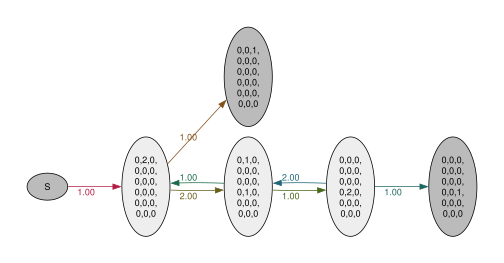

In [22]:
from phasic import StateIndexer, Property, DataPrior

nr_im = 2

indexer_im = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_im),
        Property('pop2', min_value=0, max_value=nr_im),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_im = [0] * indexer_im.state_length
initial_im[indexer_im.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_im

@with_ipv(initial_im)
def im_model_bab(state):
    """
    IM-model (to-ø epoke).
    Parametre: [theta0, theta1, epoch_switch]
    theta0      = koalescensrate (1/N)
    theta1      = migrationsrate
    epoch_switch = rate for epoch-skift (sættes til 1/t_s)
    """
    transitions = []
    if state[indexer_im.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_im.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_im.descendants.index_to_props(i)
        for j in range(i, indexer_im.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_im.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_im.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1,
                pop2=pi.pop2+pj.pop2,
                in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_im.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_im.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i], 0]])
    return transitions

g_im = Graph(im_model_bab)
print(f"IM-model: {g_im.vertices_length()} tilstande")
g_im.plot(rankdir='LR', nodesep=0.2)

In [ ]:
# Data: P. anubis + P. cynocephalus
data_anubis  = sfs_to_tmrca_proxy(df_P_anubis, n_obs=3000)
data_cyno_im = sfs_to_tmrca_proxy(df_P_cynocephalus, n_obs=3000)
data_im_combined = np.concatenate([data_anubis, data_cyno_im])

# Start-estimater fra N_ref
N_a  = N_ref_dict['P. anubis']
N_c2 = N_ref_dict['P. cynocephalus']
theta0_im_start = 1.0 / ((N_a + N_c2) / 2)

# Vælg et rimeligt start epoch_switch
# t_s ~ 1 coalescent-enhed svarer til 2*N_ref generationer ≈ 200,000 år for N~10,000
epoch_switch_start = 1.0  # 1/t_s, dvs. t_s = 1 coalescent-enhed

g_im.update_weights([theta0_im_start, 0.5, epoch_switch_start])

prior_im = [
    GaussPrior(ci=[theta0_im_start * 0.1, theta0_im_start * 10]),  # theta0
    GaussPrior(ci=[0.01, 5.0]),                                      # migration
    GaussPrior(ci=[0.1, 10.0]),                                      # epoch_switch
]

print(f"Start-estimater:")
print(f"  θ₀ = {theta0_im_start:.5f}  (N_ref = {(N_a+N_c2)/2:.0f})")
print(f"  θ₁ = 0.5  (startgæt for migration)")
print(f"  epoch = {epoch_switch_start:.2f}  (t_s ≈ 1 koalescent-enhed)")

In [ ]:
# Kør SVGD på IM-modellen
sv_im = g_im.svgd(
    data_im_combined,
    prior=prior_im,
    optimizer=Adam(0.25),
    n_iterations=350,
)
res_im = sv_im.get_results()

theta0_im  = res_im['theta_mean'][0].item()
theta1_im  = res_im['theta_mean'][1].item()
epoch_im   = res_im['theta_mean'][2].item()

Ne_im      = 1.0 / theta0_im if theta0_im > 0 else np.nan
t_s_coal   = 1.0 / epoch_im if epoch_im > 0 else np.nan
t_s_gen    = t_s_coal * 2 * Ne_im if not np.isnan(Ne_im) else np.nan
t_s_years  = t_s_gen * GEN if not np.isnan(t_s_gen) else np.nan

print("IM-model estimater (P. anubis + P. cynocephalus):")
print(f"  θ₀ (koalescens)  = {theta0_im:.5f} ± {res_im['theta_std'][0].item():.5f}")
print(f"  θ₁ (migration)   = {theta1_im:.4f} ± {res_im['theta_std'][1].item():.4f}")
print(f"  epoch-switch     = {epoch_im:.4f} ± {res_im['theta_std'][2].item():.4f}")
print()
print("Biologiske enheder:")
print(f"  N_e ≈ {Ne_im:.0f} individer")
print(f"  t_s ≈ {t_s_coal:.2f} koalescent-enheder")
print(f"  t_s ≈ {t_s_gen:.0f} generationer")
print(f"  t_s ≈ {t_s_years:.0f} år  (ved g={GEN} år/generation)")
print(f"  m per generation ≈ {theta1_im / (2 * Ne_im):.6f}" if Ne_im > 0 else "")

In [ ]:
# IM-model graf med bavian-parametre
g_im.update_weights([theta0_im, theta1_im, epoch_im])
print(f"IM-model med estimerede bavian-parametre:")
print(f"  θ₀ = {theta0_im:.5f}  (P. anubis + P. cynocephalus)")
print(f"  θ₁ = {theta1_im:.4f}")
print(f"  epoch = {epoch_im:.4f}")
g_im.plot()

In [ ]:
sv_im.summary()

In [ ]:
# Visualiser IM-model resultater
sv_im.plot_convergence()
sv_im.plot_pairwise()

In [ ]:
sv_im.plot_ci()

In [ ]:
sv_im.plot_trace()

In [ ]:
sv_im.plot_hdr()

In [ ]:
sv_im.animate_pairwise()

In [ ]:
# Sammenlign: Two-island vs. IM-model
print("=== Sammenligning: Two-island vs. IM-model ===")
print()
print(f"{'Model':<20} {'θ₀':>10} {'θ₁':>10} {'N_e':>12} {'t_s (år)':>12}")
print("-" * 70)
print(f"{'Two-island':<20} {theta0_hat:>10.5f} {theta1_hat:>10.4f} "
      f"{1/theta0_hat:>12.0f} {'N/A':>12}")
print(f"{'IM-model':<20} {theta0_im:>10.5f} {theta1_im:>10.4f} "
      f"{Ne_im:>12.0f} {t_s_years:>12.0f}")

# E[TMRCA] under begge modeller
g_two.update_weights([theta0_hat, theta1_hat])
g_im.update_weights([theta0_im, theta1_im, epoch_im])
print()
print(f"E[TMRCA] two-island: {g_two.expectation():.4f} koalescent-enheder")
print(f"E[TMRCA] IM-model:   {g_im.expectation():.4f} koalescent-enheder")

## E[TMRCA] som funktion af migrationsrate

Jeg undersøger, hvordan den forventede TMRCA ændrer sig med migrationsraten for de estimerede populationsparametre. Dette viser, hvor sensitiv modellen er over for migration, og om det estimerede $\theta_1$ befinder sig i et diagnostisk interessant parameterrum.

In [ ]:
# E[TMRCA] som funktion af t_s (split-tidspunkt) ved estimerede parametre
t_s_values = np.linspace(0.1, 5.0, 40)
E_im_ts = []

for t_s in t_s_values:
    g_im.update_weights([theta0_im, theta1_im, 1.0/t_s])
    E_im_ts.append(g_im.expectation())

# Two-island reference (ingen split)
g_two.update_weights([theta0_hat, theta1_hat])
E_two_ref = g_two.expectation()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_s_values, E_im_ts, 'C0-', lw=2, label='IM-model E[TMRCA]')
ax.axhline(E_two_ref, color='C1', linestyle='--', lw=2,
           label=f'Two-island E[TMRCA] = {E_two_ref:.3f}')
ax.axvline(t_s_coal, color='red', linestyle=':', lw=2,
           label=f'Estimeret t_s = {t_s_coal:.2f}')
ax.set_xlabel('Split-tidspunkt $t_s$ (koalescent-enheder)')
ax.set_ylabel('E[TMRCA]')
ax.set_title('IM-model: E[TMRCA] som funktion af split-tidspunkt'
             '(P. anubis + P. cynocephalus)')
ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
migration_range = np.logspace(-2, 1, 50)
E_tmrca_vals = []
Var_tmrca_vals = []

for m in migration_range:
    g_two.update_weights([theta0_hat, m])
    E_tmrca_vals.append(g_two.expectation())
    Var_tmrca_vals.append(g_two.variance())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(migration_range, E_tmrca_vals, color='C0')
axes[0].axvline(theta1_hat, color='red', linestyle='--',
                label=f'Estimeret θ₁={theta1_hat:.3f}')
axes[0].set_xlabel('Migrationsrate θ₁'); axes[0].set_ylabel('E[TMRCA]')
axes[0].set_title('E[TMRCA] vs. migration (bavian-parametre)')
axes[0].legend()

axes[1].semilogx(migration_range, Var_tmrca_vals, color='C1')
axes[1].axvline(theta1_hat, color='red', linestyle='--',
                label=f'Estimeret θ₁={theta1_hat:.3f}')
axes[1].set_xlabel('Migrationsrate θ₁'); axes[1].set_ylabel('Var[TMRCA]')
axes[1].set_title('Var[TMRCA] vs. migration (bavian-parametre)')
axes[1].legend()
plt.tight_layout(); plt.show()